In [2]:
import pandas
import matplotlib.pyplot as plt

dataset = pandas.read_csv("salesdaily.csv")


M01AB: 10600.937083334 sales
N02BA: 8172.209000000999 sales
N02BE: 63005.40270834 sales
N05B: 18645.737499971 sales
N05C: 1249.958333333 sales
R03: 11608.822916672001 sales
R06: 6107.8175 sales

N02BE has the highest total sales.
Total sales of all drugs: 119390.885041651


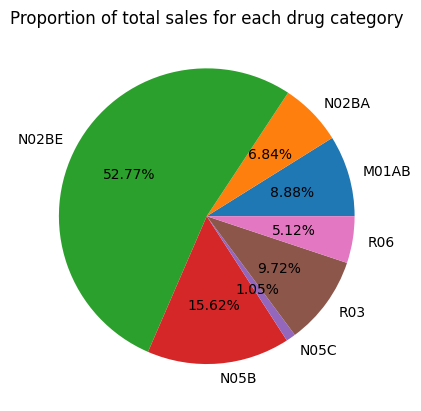

In [43]:
# What are the total sales quantities for each drug category (ATC code)?
categories = ["M01AB", "N02BA", "N02BE", "N05B", "N05C", "R03", "R06"]

data = [dataset[col].sum() for col in categories]
for i, category in enumerate(categories):
    print(f"{category}: {data[i]} sales")

highest_sales = dataset[categories].sum().idxmax()

# Which individual drug brands have the highest total sales?
print()
print(f"{highest_sales} has the highest total sales.")
print(f"Total sales of all drugs: {sum(data)}")

plt.pie(data, labels=categories, autopct="%1.2f%%")
plt.title("Proportion of total sales for each drug category")
plt.show()

Top 3 drugs in January 2015: 
N02BE    1044.24
N05B      463.00
R03       177.25
Top 3 drugs in July 2016: 
N02BE    652.362000
N05B     240.000000
M01AB    194.528333
Top 3 drugs in September 2017: 
N02BE    863.75
N05B     223.00
R03      139.00


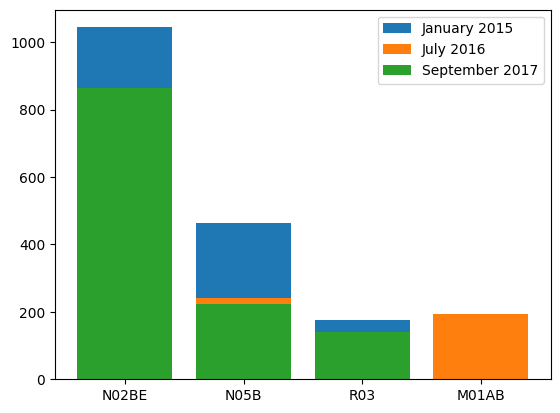

In [64]:
# Which three drugs have the highest sales in January 2015, July 2016, September 2017.

# Convert the 'datum' column to datetime objects for easier filtering
dataset["datum"] = pandas.to_datetime(dataset["datum"])

# use elementwise '&' and parentheses to build boolean masks
jan_mask = (dataset["datum"].dt.month == 1) & (dataset["datum"].dt.year == 2015)
jul_mask = (dataset["datum"].dt.month == 7) & (dataset["datum"].dt.year == 2016)
sep_mask = (dataset["datum"].dt.month == 9) & (dataset["datum"].dt.year == 2017)

top_jan_drug = dataset.loc[jan_mask, categories].sum().sort_values(ascending=False).head(3)
top_jul_drug = dataset.loc[jul_mask, categories].sum().sort_values(ascending=False).head(3)
top_sep_drug = dataset.loc[sep_mask, categories].sum().sort_values(ascending=False).head(3)

print(f"Top 3 drugs in January 2015: \n{top_jan_drug.to_string()}")
print(f"Top 3 drugs in July 2016: \n{top_jul_drug.to_string()}")
print(f"Top 3 drugs in September 2017: \n{top_sep_drug.to_string()}")

plt.bar(top_jan_drug.index, top_jan_drug.values, label="January 2015")
plt.bar(top_jul_drug.index, top_jul_drug.values, label="July 2016")
plt.bar(top_sep_drug.index, top_sep_drug.values, label="September 2017")
plt.legend()
